## Short Term Memory Basics

In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [ ]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

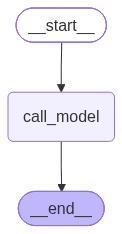

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Suman."}]})

{'messages': [HumanMessage(content='Hi! My name is Suman.', additional_kwargs={}, response_metadata={}, id='11b1030f-0c94-44e7-9678-8733a5e5355b'),
  AIMessage(content='Hi Suman! Nice to meet you. How can I help today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 14, 'total_tokens': 32, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElZlnKgrjsYpuFP3Mu2znuBvSMGi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cb7-7300-7223-9865-1f00444e3589-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 18, 'total_tokens': 32, 'input_token_details': 

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b4fab1b7-2850-4791-bbe3-5c1a4b1475c5'),
  AIMessage(content='I don’t know your name from this conversation alone. If you’d like, tell me your name and I can use it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 11, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElZvROnTWnGrhg0i6vlDDQYKUvao', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cb7-9f7e-79e3-b7e7-87b492ee1c02-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens'

## Adding In-memory

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Suman"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Suman', additional_kwargs={}, response_metadata={}, id='c21e595b-8de0-408d-8c0d-7343022b1564'),
  AIMessage(content='Hi Suman! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 13, 'total_tokens': 32, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElaaqfd7a9gsYLwFXojYgSOzTUfC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cb8-4081-7b80-8e1f-2a65c16c29e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 19, 'total_tokens': 32, 'input_token_details

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='34aeb4c9-5d6c-4c50-943b-9038002ec2ea'),
  AIMessage(content='I don’t know your name unless you tell me. If you’d like, you can share it and I’ll use it.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 11, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElajYwEiIiUlFw3Wg5xKExUmXyZU', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cb8-624f-70c2-890a-a5149386a239-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 29, 'total

In [16]:
graph.invoke({"messages": [{"role": "user", "content": "what is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Suman', additional_kwargs={}, response_metadata={}, id='c21e595b-8de0-408d-8c0d-7343022b1564'),
  AIMessage(content='Hi Suman! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 13, 'total_tokens': 32, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElaaqfd7a9gsYLwFXojYgSOzTUfC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cb8-4081-7b80-8e1f-2a65c16c29e9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 19, 'total_tokens': 32, 'input_token_details

In [17]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Suman
- AIMessage : Hi Suman! Nice to meet you. How can I help you today?
- HumanMessage : what is my name?
- AIMessage : Your name is Suman.


## Adding database as checkpointers

In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

In [19]:
load_dotenv()

True

In [20]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [21]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [22]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [23]:
conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
# Checkpointer
checkpointer = SqliteSaver(conn=conn)

In [24]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

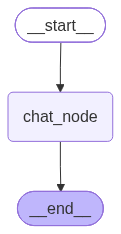

In [25]:
chatbot

In [26]:
initial_state = {
    'messages': [HumanMessage(content='My name is Suman')]
}

In [27]:
config = {'configurable': {'thread_id': 'thread-1'}}

In [28]:
final_state = chatbot.invoke(initial_state, config=config)

In [29]:
import pprint
pprint.pprint(final_state["messages"][-1].content)

'Nice to meet you, Suman. How can I help you today?'


In [30]:
final_state

{'messages': [HumanMessage(content='My name is Suman', additional_kwargs={}, response_metadata={}, id='ebd9544b-b096-4e69-97ca-7b41f736ab16'),
  AIMessage(content='Nice to meet you, Suman. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 11, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EElkPd98FjZuC9Dfbjkt4t60UlGQ1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01cc1-85b4-7a20-92ec-5b10ac613f2d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 18, 'total_tokens': 29, 'input_token_details': {'au

### Read the SQLite thread from outside

The checkpointer lives in `chatbot.db`. A new process can reopen that file, compile the same graph, and use the same `thread_id`. You do not need the original `chatbot` object.

`get_state` only **reads** the saved checkpoint. It does not call the LLM.

Use `invoke` only when you want a **new** turn, for example sending another user message.

In [31]:
# Compile with the DB only so we can *read* checkpoints. No new LLM call.
DB_URI = "chatbot.db"
t1 = {"configurable": {"thread_id": "thread-1"}}

with SqliteSaver.from_conn_string(DB_URI) as cp:
    outside_graph = (
        StateGraph(ChatState)
        .add_node("chat_node", chat_node)
        .add_edge(START, "chat_node")
        .add_edge("chat_node", END)
        .compile(checkpointer=cp)
    )

    snap = outside_graph.get_state(t1)  # pulls from SQLite, does not run the graph
    msgs = snap.values.get("messages", [])

    print("Messages stored for thread-1:")
    for m in msgs:
        print("-", type(m).__name__, ":", m.content)

    print("\nLast message:", msgs[-1].content if msgs else None)

Messages stored for thread-1:
- HumanMessage : My name is Suman
- AIMessage : Nice to meet you, Suman. How can I help you today?

Last message: Nice to meet you, Suman. How can I help you today?


In [33]:
# from_conn_string closes the DB when the `with` block ends.
# invoke must run *inside* the with, while the connection is still open.
with SqliteSaver.from_conn_string("chatbot.db") as cp:
    outside_graph = (
        StateGraph(ChatState)
        .add_node("chat_node", chat_node)
        .add_edge(START, "chat_node")
        .add_edge("chat_node", END)
        .compile(checkpointer=cp)
    )
    result = outside_graph.invoke(
        {"messages": [HumanMessage(content="What is my name?")]},
        config={"configurable": {"thread_id": "thread-1"}},
    )

print(result["messages"][-1].content)

Your name is Suman.
